【Data Scaling(데이터 스케일링)】
- 서로 다른 변수의 값 범위를 일정한 수준으로 맞추는 작업을 피처 스케일링(feature scaling)이라고 한다.
- 피처(feature)=컬럼(column) 들마다 데이터의 값이 범위가 다 제각각이거나 단위가 다른 경우 데이터를 학습을 할때 0으로 수렴하거나 무한으로 발산할 수 있다.
  - 분석시에 변수들이 너무 스케일이 다를 경우  => 변수들의 단위 차이로 인해 숫자의 스케일이 크게 달라지는 경우
  - 신경망 학습시에 => 데이터셋의 값이 들쑥날쑥하거나, 매우 큰 경우에는 cost의 값이 발산하여 정상적인 학습이 이루어지지 않습니다.

- 이런 경우 데이터 스켈링을 통해 모든 피처들의 데이터 분포나 범위를 동일하게 조정해 줄 수 있다.
- Scaling 메서드는 scikit-learn의 preprocessing에서 제공한다.
- sklearn에서 제공하는 기본 Scaling 종류
   - StandardScaler : 평균이 0 분산이 1인 정규분포로 변환
   - MinMaxScaler :  0 ~ 1 사이의 실수로 변환, 타이타닉 생존자 예측(0 또는 1)과 같은 분류 문제보다는, 아파트 실거래가격 예측과 같은 회귀 문제를 해결할 때 더 적합한 스케일링 기법
   - RobustScaler : 중앙값이 0, 중앙값을 0으로, IQR을 1로 변환, StandardScaler에 비해 이상치의 영향이 적어진다는 장점
   - MaxAbsScaler : 모든 피처들의 절댓값이 0과 1 사이에 놓이도록 변환, 극단적인 이상치에는 민감할 수 있으므로 꼭 이상치를 제거
   - Normalizer :  row를 기준으로 row(data point)마다 정규화를 진행, 한 행의 모든 features 사이에 유클리드 거리가 1이 되도록 데이터값을 변환, Normalizer를 사용하면 학습 속도도 빨라지고 과대적합 확률을 낮춤

In [1]:
# '파이썬 라이브러리를 활용한 머신러닝'의 저자가 제공한 라이브러리
# !uv add mglearn

In [2]:
import mglearn

In [3]:
print(dir(mglearn))

['ReBl', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'cm2', 'cm3', 'datasets', 'discrete_scatter', 'plot_2d_separator', 'plot_agglomerative', 'plot_animal_tree', 'plot_cross_validation', 'plot_dbscan', 'plot_decomposition', 'plot_grid_search', 'plot_helpers', 'plot_improper_preprocessing', 'plot_interactive_tree', 'plot_kmeans', 'plot_kneighbors_regularization', 'plot_knn_classification', 'plot_knn_regression', 'plot_linear_regression', 'plot_linear_svc_regularization', 'plot_metrics', 'plot_nmf', 'plot_nn_graphs', 'plot_pca', 'plot_rbf_svm_parameters', 'plot_ridge', 'plot_scaling', 'plot_tree_nonmonotonous', 'plots', 'tools']


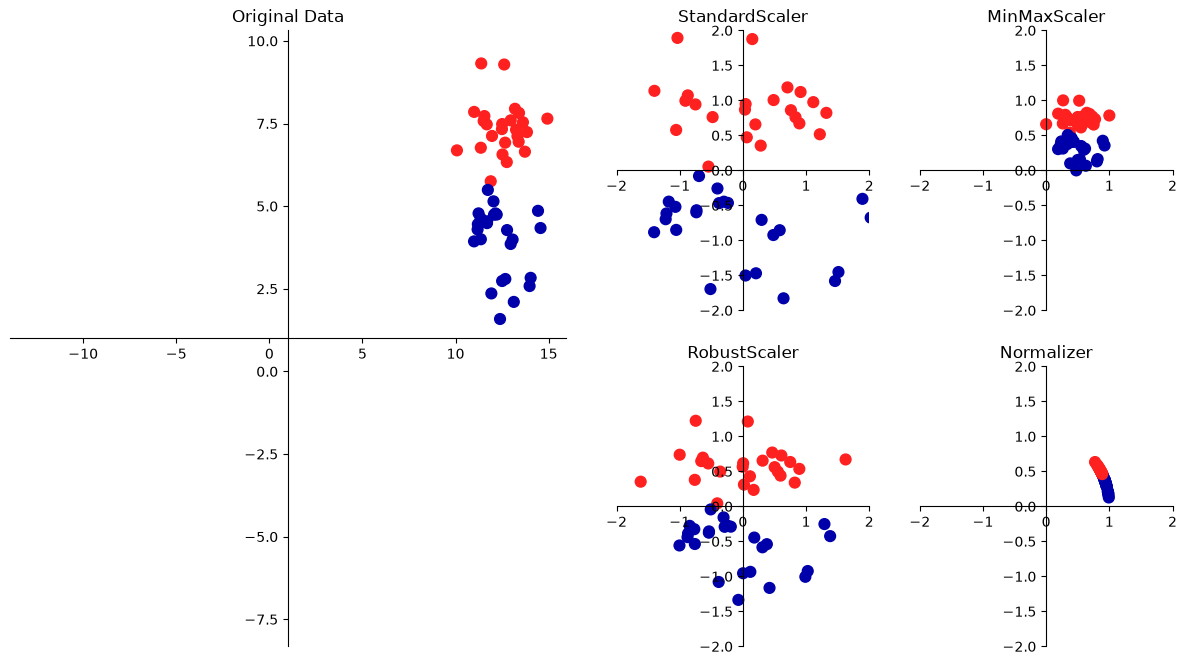

In [4]:
mglearn.plot_scaling.plot_scaling()

1. ## **`MaxAbsScaler`**

- 데이터의 **절대값이 1을 넘지 않도록** 스케일링
- 음수와 양수 값이 섞인 sparse 데이터에 적합
- 이상치에 민감하며, 분류보다는 회귀분석에서 유용


In [5]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform([[-1, 23], [0, 3], [1, -2]])
X_scaled


array([[-1.        ,  1.        ],
       [ 0.        ,  0.13043478],
       [ 1.        , -0.08695652]])

2. MinMaxScaler

- **최소-최대 정규화**: 데이터를 `[0, 1]` 범위로 변환
- 정규분포가 아닐때 사용
- 이상치에 민감
- 분류보다 회귀에 유용

In [6]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform([[1, 2], [3, 4], [5, 6]])
X_scaled


array([[0. , 0. ],
       [0.5, 0.5],
       [1. , 1. ]])

2.3 StandardScaler

- **Z-score 정규화**: 평균을 0, 표준편차를 1로 변환
- 이상치 영향을 받으므로 이상치가 없을때 사용
- 회귀보다는 분류분석에서 유용

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform([[1, 2], [3, 4], [5, 6]])
X_scaled


array([[-1.22474487, -1.22474487],
       [ 0.        ,  0.        ],
       [ 1.22474487,  1.22474487]])

2.4 Normalizer
- 각 행의 벡터 크기를 1로 정규화 (L1, L2, Max 노름 사용 가능)

In [8]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer(norm='l2')
X_normalized = normalizer.transform([[1, 2], [3, 4]])
X_normalized


array([[0.4472136 , 0.89442719],
       [0.6       , 0.8       ]])

2.5 RobustScaler
- **중앙값과 IQR(사분위 범위) 기반 정규화**
- 이상치(Outlier)에 강한 정규화 방법

In [9]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

# 예제 데이터
data = {
    'Income': [3000, 3200, 3400, 100000, 3600],  # 이상치 존재
    'Age': [25, 26, 27, 28, 29]
}
df = pd.DataFrame(data)
print(" 원본 데이터:\n", df)

# RobustScaler 객체 생성 및 적용
scaler = RobustScaler()
scaled_data = scaler.fit_transform(df)

# 결과를 DataFrame으로 변환
df_scaled = pd.DataFrame(scaled_data, columns=['Income_scaled', 'Age_scaled'])
print("RobustScaler 결과:\n", df_scaled)

# 3          241.5         0.5  이상이 영향 작음

 원본 데이터:
    Income  Age
0    3000   25
1    3200   26
2    3400   27
3  100000   28
4    3600   29
RobustScaler 결과:
    Income_scaled  Age_scaled
0           -1.0        -1.0
1           -0.5        -0.5
2            0.0         0.0
3          241.5         0.5
4            0.5         1.0


| Feature 이름          | 설명      | 단위 |
| ------------------- | ------- | -- |
| `sepal length (cm)` | 꽃받침의 길이 | cm |
| `sepal width (cm)`  | 꽃받침의 너비 | cm |
| `petal length (cm)` | 꽃잎의 길이  | cm |
| `petal width (cm)`  | 꽃잎의 너비  | cm |


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import RobustScaler

In [11]:
iris = load_iris()
print(dir(iris))
print(iris.target)

iris = pd.DataFrame(iris.data, columns=iris.feature_names)

iris['Class'] = load_iris().target
iris['Class'] = iris['Class'].map({0:'Setosa', 1:'Versicolour', 2:'Virginica'})
iris.head()

['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Class
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [12]:
from sklearn.model_selection import train_test_split


#X_관측값_훈련,X_관측값_테스트,y_정답_훈련,y_정답_테스트
X_train, X_test, y_train, y_test = train_test_split(iris.drop(columns='Class'), iris['Class'],   test_size=0.2, stratify=iris["Class"]) #  test_size=0.25.



In [13]:
X_train.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
63,6.1,2.9,4.7,1.4
12,4.8,3.0,1.4,0.1
98,5.1,2.5,3.0,1.1
142,5.8,2.7,5.1,1.9
8,4.4,2.9,1.4,0.2


In [14]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(120, 4) (120,)
(30, 4) (30,)


In [15]:
print(y_train.value_counts())

Class
Versicolour    40
Setosa         40
Virginica      40
Name: count, dtype: int64


In [16]:
print(y_test.value_counts())

Class
Setosa         10
Virginica      10
Versicolour    10
Name: count, dtype: int64


In [17]:
import seaborn as sns

In [18]:
print(type(y_train))
print(y_train.head())

<class 'pandas.Series'>
63     Versicolour
12          Setosa
98     Versicolour
142      Virginica
8           Setosa
Name: Class, dtype: str


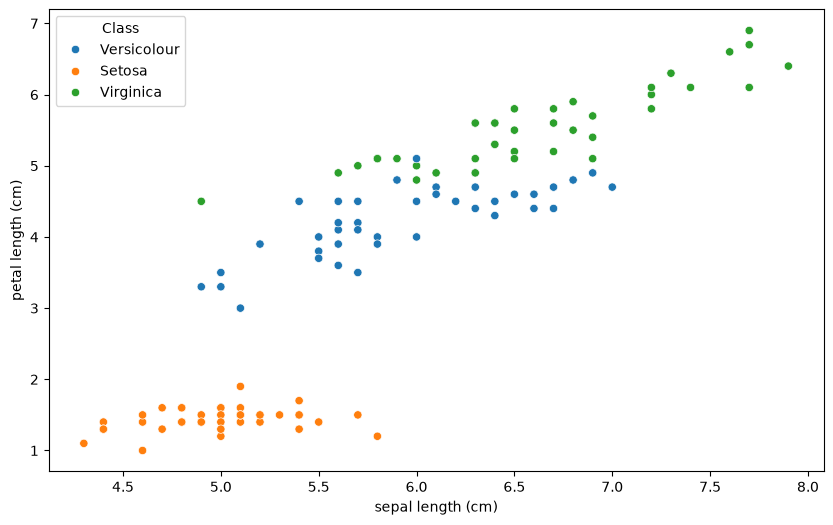

In [19]:
fig =sns.scatterplot(data=X_train, x=X_train.iloc[:,0], y=X_train.iloc[:,2], hue=y_train)
fig.figure.set_size_inches(10,6)

In [20]:
StdScaler = StandardScaler()

# Train데이터의 fitting과 스케일링
StdScaler.fit(X_train)  #fit()은 학습을 시키는 메소드이다.
X_train_sc = StdScaler.transform(X_train)  #transform() 실제로 학습시킨 것을 적용하는 메소드이다.

print('\t\t(min, max)  (mean,std)')
print('Train_scaled (%.2f, %.2f) ( %.2f, %.2f)'%(X_train_sc.min(), X_train_sc.max(), X_train_sc.mean(),X_train_sc.std()))

		(min, max)  (mean,std)
Train_scaled (-2.35, 3.03) ( 0.00, 1.00)


In [21]:
StdScaler2 = StandardScaler()
StdScaler2.fit_transform(X_train)

array([[ 0.30834954, -0.33410469,  0.54543382,  0.27222346],
       [-1.22847246, -0.11012389, -1.3278688 , -1.44708259],
       [-0.87382123, -1.23002789, -0.41960086, -0.12453948],
       [-0.04630169, -0.78206629,  0.7725008 ,  0.93349501],
       [-1.70134077, -0.33410469, -1.3278688 , -1.31482828],
       [-0.28273584, -0.11012389,  0.43190032,  0.40447777],
       [ 1.84517155, -0.55808549,  1.34016826,  0.93349501],
       [-1.81955785, -0.11012389, -1.49816903, -1.44708259],
       [ 0.78121785, -0.11012389,  0.82926755,  1.06574932],
       [ 1.01765201, -0.11012389,  0.82926755,  1.46251226],
       [-0.87382123,  1.00978011, -1.3278688 , -1.18257396],
       [-0.16451877, -0.11012389,  0.26160009,  0.00771483],
       [-0.04630169, -1.00604709,  0.1480666 ,  0.00771483],
       [ 1.01765201, -1.23002789,  1.16986802,  0.8012407 ],
       [ 1.01765201,  0.11385691,  1.05633453,  1.59476657],
       [-0.04630169,  2.12968411, -1.44140229, -1.31482828],
       [ 1.72695447, -0.

In [22]:
xt = pd.DataFrame(X_train_sc.T)
xt

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,0.308350,-1.228472,-0.873821,-0.046302,-1.701341,-0.282736,1.845172,-1.819558,0.781218,1.017652,...,0.781218,-0.873821,0.544784,-0.992038,-0.755604,1.254086,-1.701341,-0.282736,-0.519170,-0.519170
1,-0.334105,-0.110124,-1.230028,-0.782066,-0.334105,-0.110124,-0.558085,-0.110124,-0.110124,-0.110124,...,-0.110124,1.681723,0.785799,1.009780,1.009780,0.113857,-0.110124,-0.558085,1.905703,1.905703
2,0.545434,-1.327869,-0.419601,0.772501,-1.327869,0.431900,1.340168,-1.498169,0.829268,0.829268,...,0.999568,-1.044035,1.056335,-1.384636,-1.271102,0.658967,-1.384636,0.658967,-1.157569,-1.384636
3,0.272223,-1.447083,-0.124539,0.933495,-1.314828,0.404478,0.933495,-1.447083,1.065749,1.462512,...,0.801241,-1.050320,1.594767,-1.182574,-1.314828,0.404478,-1.314828,1.065749,-1.050320,-1.050320


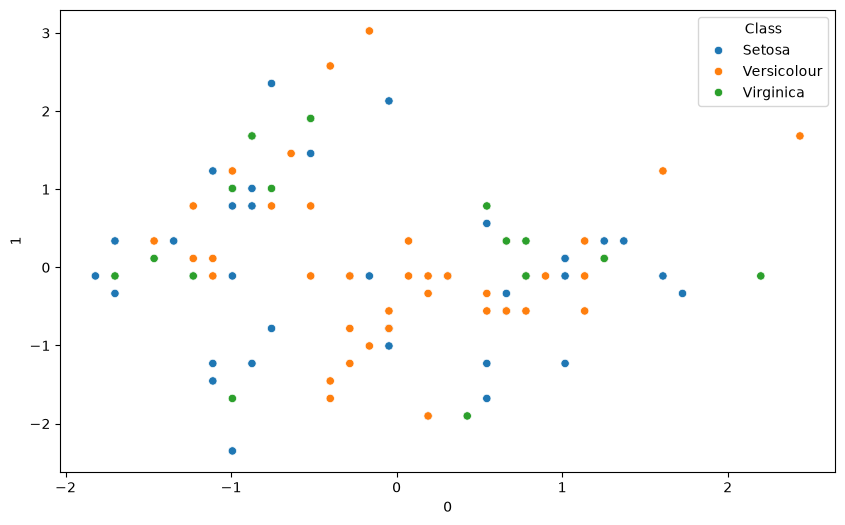

In [23]:
fig =sns.scatterplot(data=xt, x=xt.iloc[0,:], y=xt.iloc[1,], hue=y_train)
fig.figure.set_size_inches(10,6)

In [24]:
from sklearn.preprocessing import MinMaxScaler

MmScaler = MinMaxScaler()

# Train 데이터의 fitting과 스케일링
# fit()은 학습을 시키는 메소드이다.
MmScaler.fit(X_train)

#transform()은 실제로 학습시킨 것을 적용하는 메소드이다.
X_train_sc = MmScaler.transform(X_train)
print(X_train_sc.shape)

print('\t\t(min, max)  (mean,std)')
print('Train_scaled (%.2f, %.2f) ( %.2f, %.2f)'%(X_train_sc.min(), X_train_sc.max(), X_train_sc.mean(),X_train_sc.std()))

(120, 4)
		(min, max)  (mean,std)
Train_scaled (0.00, 1.00) ( 0.45, 0.26)


(480,)


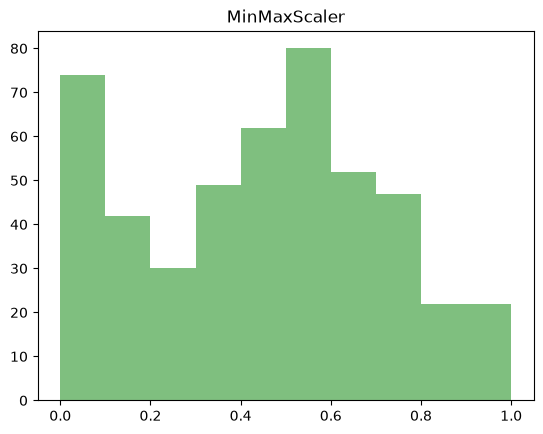

In [25]:
X_train_sc_flat = X_train_sc.flatten()
print(X_train_sc_flat.shape)
#print(X_train_sc_flat)
plt.hist(X_train_sc_flat, color='green', alpha=0.5)
plt.title('MinMaxScaler')
plt.show()

In [26]:
xt = pd.DataFrame(X_train_sc).T

In [27]:
xt.iloc[0, :].shape

(120,)

In [28]:
xt.iloc[1, :].shape

(120,)

In [29]:
xt.shape

(4, 120)

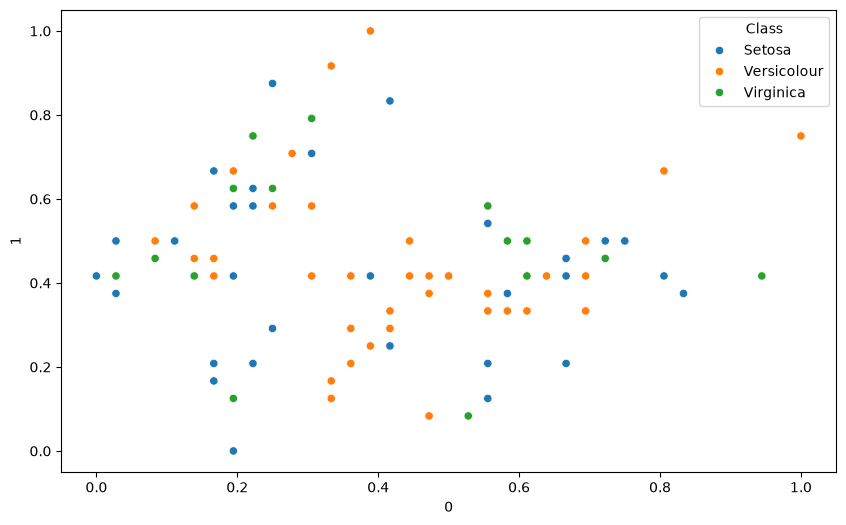

In [30]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)

In [31]:
from sklearn.preprocessing import MaxAbsScaler

MaScaler = MaxAbsScaler()

# Train 데이터의 fitting과 스케일링
MaScaler.fit(X_train)
X_train_sc = MaScaler.transform(X_train)


print("\t\t(min, max) (mean, std)")
print("Train_scaled (%.2f, %.2f) (%.2f, %.2f)"%(X_train_sc.min(), X_train_sc.max(),  X_train_sc.mean(),  X_train_sc.std()))

		(min, max) (mean, std)
Train_scaled (0.04, 1.00) (0.61, 0.24)


In [32]:
X_train_sc.shape

(120, 4)

In [33]:
xt = pd.DataFrame(X_train_sc.T)
xt

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,0.772152,0.607595,0.645570,0.734177,0.556962,0.708861,0.936709,0.544304,0.822785,0.848101,...,0.822785,0.645570,0.797468,0.632911,0.658228,0.873418,0.556962,0.708861,0.683544,0.683544
1,0.659091,0.681818,0.568182,0.613636,0.659091,0.681818,0.636364,0.681818,0.681818,0.681818,...,0.681818,0.863636,0.772727,0.795455,0.795455,0.704545,0.681818,0.636364,0.886364,0.886364
2,0.681159,0.202899,0.434783,0.739130,0.202899,0.652174,0.884058,0.159420,0.753623,0.753623,...,0.797101,0.275362,0.811594,0.188406,0.217391,0.710145,0.188406,0.710145,0.246377,0.188406
3,0.560000,0.040000,0.440000,0.760000,0.080000,0.600000,0.760000,0.040000,0.800000,0.920000,...,0.720000,0.160000,0.960000,0.120000,0.080000,0.600000,0.080000,0.800000,0.160000,0.160000


In [34]:
xt.shape

(4, 120)

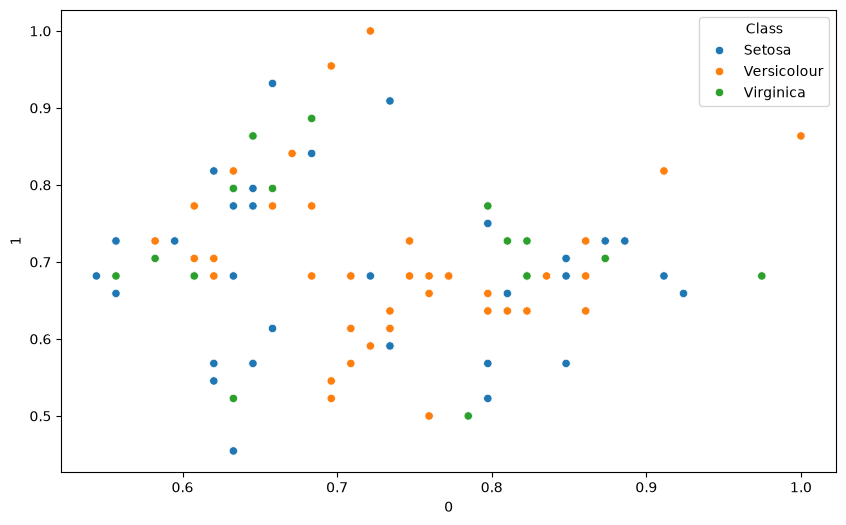

In [35]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)

In [36]:
from sklearn.preprocessing import RobustScaler

RuScaler = RobustScaler()

# Train 데이터의 fitting과 스케일링
RuScaler.fit(X_train)
X_train_sc = RuScaler.transform(X_train)

print("\t\t(min, max) (mean, std)")
print("Train_scaled (%.2f, %.2f) (%.2f, %.2f)"%(X_train_sc.min(), X_train_sc.max(),  X_train_sc.mean(),  X_train_sc.std()))

		(min, max) (mean, std)
Train_scaled (-2.50, 3.50) (-0.02, 0.74)


In [37]:
xt = pd.DataFrame(X_train_sc.T)
xt

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,0.264151,-0.716981,-0.490566,0.037736,-1.018868,-0.113208,1.245283,-1.094340,0.566038,0.716981,...,0.566038,-0.490566,0.415094,-0.566038,-0.415094,0.867925,-1.018868,-0.113208,-0.264151,-0.264151
1,-0.250000,0.000000,-1.250000,-0.750000,-0.250000,0.000000,-0.500000,0.000000,0.000000,0.000000,...,0.000000,2.000000,1.000000,1.250000,1.250000,0.250000,0.000000,-0.500000,2.250000,2.250000
2,0.083333,-0.833333,-0.388889,0.194444,-0.833333,0.027778,0.472222,-0.916667,0.222222,0.222222,...,0.305556,-0.694444,0.333333,-0.861111,-0.805556,0.138889,-0.861111,0.138889,-0.750000,-0.861111
3,0.066667,-0.800000,-0.133333,0.400000,-0.733333,0.133333,0.400000,-0.800000,0.466667,0.666667,...,0.333333,-0.600000,0.733333,-0.666667,-0.733333,0.133333,-0.733333,0.466667,-0.600000,-0.600000


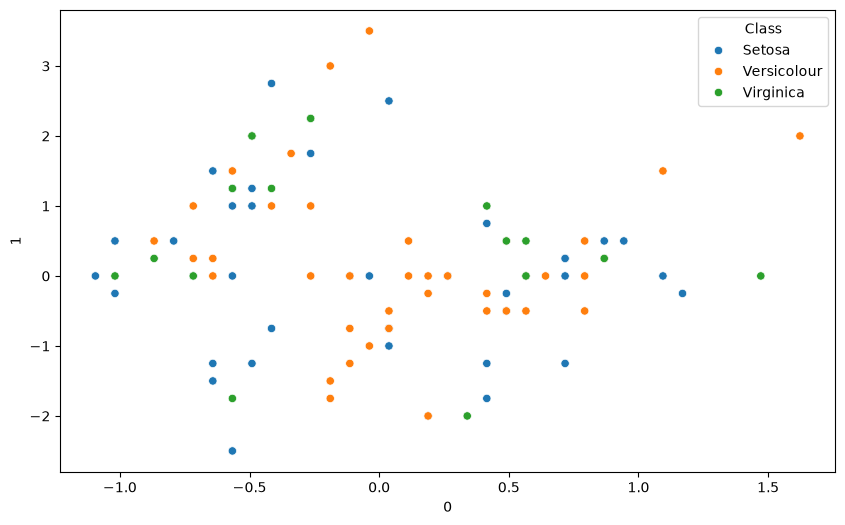

In [38]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)

In [39]:
from sklearn.preprocessing import Normalizer

NoScaler = Normalizer()


# Train 데이터의 fitting과 스케일링
NoScaler.fit(X_train)
X_train_sc = NoScaler.transform(X_train)


print("\t\t(min, max) (mean, std)")
print("Train_scaled (%.2f, %.2f) (%.2f, %.2f)"%(X_train_sc.min(), X_train_sc.max(),  X_train_sc.mean(),  X_train_sc.std()))


		(min, max) (mean, std)
Train_scaled (0.01, 0.83) (0.44, 0.24)


In [40]:
xt = pd.DataFrame(X_train_sc.T)

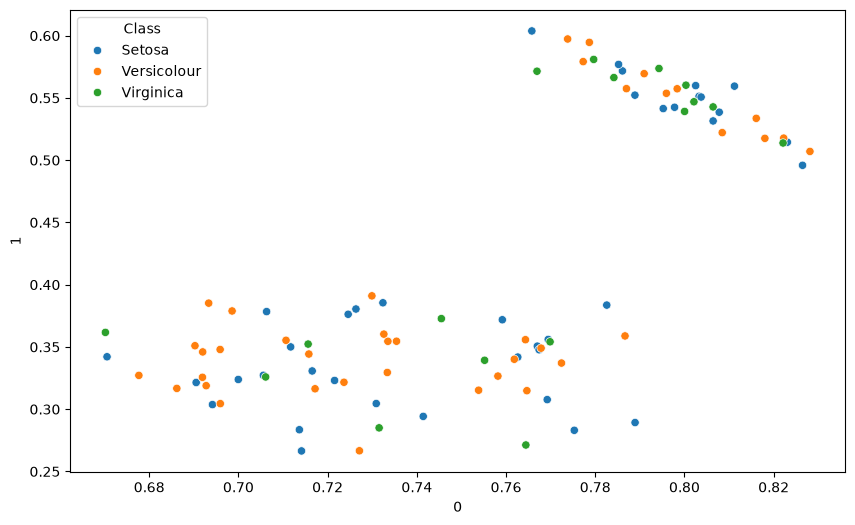

In [41]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)